# Hierarchical Clustering

## What Is Hierarchical Clustering?

Hierarchical clustering builds a **tree of clusters** called a **dendrogram**, rather than finding a flat partition of the data directly. It reveals the full nested structure of similarity in a dataset — which points are most alike, which groups merge at which distances, and how the data organizes itself at every level of granularity.

Unlike K-Means, you do not need to specify $K$ in advance. Instead, you build the full hierarchy first, then decide how many clusters you want by **cutting the dendrogram** at a chosen height.

## Two Types of Hierarchical Clustering

### Agglomerative (Bottom-Up) — Most Common

Start with every point as its own cluster ($n$ clusters). Repeatedly merge the two closest clusters until only one cluster remains. This is the standard approach and what sklearn implements by default.

### Divisive (Top-Down)

Start with all points in one cluster. Recursively split clusters until every point is its own cluster. Computationally more expensive and rarely used in practice.

In almost all practical settings, **agglomerative clustering** is what is meant by "hierarchical clustering."

## Core Mathematics: The Distance Matrix

Hierarchical clustering is built entirely on **pairwise distances**. For any two points $\mathbf{x}_i$ and $\mathbf{x}_j$, the distance is:

$$D(i, j) = \|\mathbf{x}_i - \mathbf{x}_j\|$$

For a dataset of $n$ points, this forms an $n \times n$ distance matrix. At each step of the algorithm, the two clusters with the smallest inter-cluster distance are merged.

The key question is: how do you define the distance between two **clusters** (not just two points)? This is determined by the **linkage criterion**.

## Linkage Criteria

The linkage criterion defines $D(A, B)$ — the distance between cluster $A$ and cluster $B$. The choice of linkage profoundly affects the shape and quality of the resulting clusters.

### Single Linkage

Distance between the **closest pair** of points across the two clusters:

$$D(A, B) = \min_{\mathbf{x} \in A,\ \mathbf{y} \in B} \|\mathbf{x} - \mathbf{y}\|$$

Single linkage tends to produce **elongated, chain-like clusters** because it only requires one pair of nearby points to merge two groups. It is sensitive to noise and outliers that can bridge otherwise separate clusters.

### Complete Linkage

Distance between the **farthest pair** of points across the two clusters:

$$D(A, B) = \max_{\mathbf{x} \in A,\ \mathbf{y} \in B} \|\mathbf{x} - \mathbf{y}\|$$

Complete linkage ensures all points in the merged cluster are within a bounded distance of each other. It produces **compact, roughly spherical clusters** and is more robust to outliers than single linkage.

### Average Linkage

The **mean pairwise distance** between all points across the two clusters:

$$D(A, B) = \frac{1}{|A||B|} \sum_{\mathbf{x} \in A} \sum_{\mathbf{y} \in B} \|\mathbf{x} - \mathbf{y}\|$$

Average linkage is a compromise between single and complete linkage — less susceptible to chaining than single linkage, less sensitive to outliers than complete linkage. It tends to produce balanced, moderately compact clusters.

### Ward Linkage (Most Important)

Ward linkage merges the two clusters whose combination produces the **smallest increase in total within-cluster variance**. The increase in variance when merging clusters $A$ and $B$ is:

$$\Delta(A, B) = \frac{|A||B|}{|A| + |B|} \|\mu_A - \mu_B\|^2$$

Where $\mu_A$ and $\mu_B$ are the centroids of clusters $A$ and $B$, and $|A|$, $|B|$ are their sizes. The prefactor $\frac{|A||B|}{|A|+|B|}$ is the **harmonic mean of cluster sizes**, which prevents large clusters from dominating the merge decision.

Ward linkage is the closest hierarchical analog to K-Means — it greedily minimizes:

$$\min \sum \|\mathbf{x} - \mu\|^2$$

It consistently produces **compact, equally-sized clusters** and is the default choice for most applications. If in doubt, use Ward.

| Linkage | Definition | Cluster Shape | Sensitivity |
|---|---|---|---|
| Single | Minimum distance | Elongated, chain-like | High (outliers) |
| Complete | Maximum distance | Compact, spherical | Moderate |
| Average | Mean pairwise distance | Balanced | Low–Moderate |
| Ward | Minimum variance increase | Compact, equal-sized | Low |

## The Algorithm (Agglomerative)

1. Initialize $n$ clusters — one per data point
2. Compute the full $n \times n$ pairwise distance matrix
3. Find the two clusters $A$ and $B$ with the smallest $D(A, B)$
4. Merge $A$ and $B$ into a single new cluster
5. Update the distance matrix — compute distances from the new cluster to all remaining clusters using the chosen linkage criterion
6. Repeat steps 3–5 until only one cluster remains

### Time Complexity

$$\mathcal{O}(n^3)$$

The naive implementation requires recomputing distances at every step. With optimized data structures (e.g. a priority queue), this can be reduced to $\mathcal{O}(n^2 \log n)$ for some linkages, but it remains significantly more expensive than K-Means $(\mathcal{O}(nKt))$ for large $n$.

### Determinism

Unlike K-Means, agglomerative clustering is **fully deterministic** — there is no random initialization. Given the same data and linkage, it always produces the same dendrogram.

## The Dendrogram

The dendrogram is a tree diagram that encodes the entire merge history:

- The **leaves** (bottom) are individual data points
- The **height** of each horizontal merge line represents the distance at which those two clusters were joined
- **Cutting the dendrogram at height $h$** produces clusters — all subtrees below the cut become individual clusters

To choose $K$, look for the **largest vertical gap** in the dendrogram — a region where no merges happen over a large distance range. This gap suggests a natural number of clusters at that level of the hierarchy. Cutting just below the top of this gap gives the most stable and well-separated partition.

This is the key advantage of hierarchical clustering over K-Means: you do not commit to a specific $K$ upfront. The dendrogram shows you the full spectrum of possible partitions and lets you choose one informed by the data's structure.

## Evaluation Metrics

### Silhouette Score

$$s = \frac{b - a}{\max(a,\ b)}$$

Where $a$ is the mean intra-cluster distance and $b$ is the mean distance to the nearest other cluster. Scores near $+1$ are ideal. Can be computed for any value of $K$ to validate the chosen cut.

### Davies-Bouldin Score

$$DB = \frac{1}{K}\sum_{i=1}^{K} \max_{j \neq i} \left(\frac{\sigma_i + \sigma_j}{d(\mu_i, \mu_j)}\right)$$

Where $\sigma_i$ is the average distance of points in cluster $i$ to their centroid, and $d(\mu_i, \mu_j)$ is the distance between centroids. **Lower is better** — it rewards compact clusters that are far apart.

### Calinski-Harabasz Score (Variance Ratio Criterion)

$$CH = \frac{\text{Between-cluster variance} / (K-1)}{\text{Within-cluster variance} / (n-K)}$$

**Higher is better**. It measures the ratio of separation between clusters to compactness within clusters. It tends to favor compact, well-separated clusters and is fast to compute.

## Hierarchical Clustering vs K-Means vs DBSCAN

| Property | K-Means | DBSCAN | Hierarchical |
|---|---|---|---|
| Requires $K$ in advance | Yes | No | No (optional) |
| Cluster shape | Spherical only | Arbitrary | Depends on linkage |
| Tree structure | No | No | Yes (dendrogram) |
| Deterministic | No (random init) | Mostly yes | Yes |
| Handles outliers | No | Yes | No |
| Scalability | Good — $\mathcal{O}(nKt)$ | Moderate — $\mathcal{O}(n^2)$ | Poor — $\mathcal{O}(n^3)$ |
| Global objective | Minimizes WCSS | None | None (greedy) |

### Geometric Intuition

**K-Means** draws Voronoi boundaries around centroids — every point goes to its nearest center. Boundaries are always linear.

**DBSCAN** expands density bubbles outward from dense core regions — boundaries follow the shape of the data.

**Hierarchical clustering** builds a minimum spanning tree-like structure by greedily connecting the nearest unconnected clusters — the full topology of merges is preserved in the dendrogram.

## Mathematical Perspective: Greedy Optimization

Hierarchical clustering is a **greedy algorithm** — at each step it makes the locally optimal merge (smallest distance) without reconsidering previous decisions. This is both its strength and its weakness.

**Strength:** it is deterministic, requires no initialization, and reveals full multi-scale structure.

**Weakness:** early merges are **irreversible**. If two points are merged incorrectly early in the process due to noise, that error propagates through the entire dendrogram. There is no mechanism to undo a bad merge, unlike K-Means which iteratively reassigns points.

Ward linkage is most closely related to K-Means in the sense that both minimize:

$$\sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k} \|\mathbf{x}_i - \mu_k\|^2$$

The difference is that K-Means does so iteratively with reassignment, while Ward does so greedily and irreversibly through merging.

## Limitations

**Scalability:** The $\mathcal{O}(n^3)$ complexity (or $\mathcal{O}(n^2)$ memory for the distance matrix) makes hierarchical clustering impractical for datasets with more than a few thousand points without approximation methods.

**Irreversible merges:** A bad early merge due to noise or an outlier cannot be corrected later. The entire downstream structure is affected.

**Sensitivity to linkage choice:** Different linkage criteria can produce dramatically different results on the same data. There is no universal best choice — it depends on the expected cluster geometry.

**No outlier detection:** Unlike DBSCAN, hierarchical clustering forces every point into some cluster at the final cut. There is no concept of noise points.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

X, _ = make_blobs(n_samples=300,
                  centers=4,
                  cluster_std=1.2,
                  random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

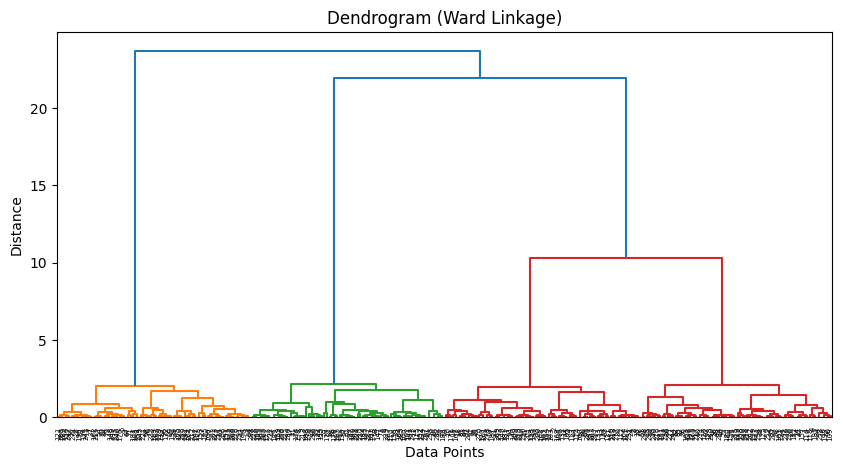

In [2]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [3]:
model = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

labels = model.fit_predict(X_scaled)

In [4]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.7582458926237312


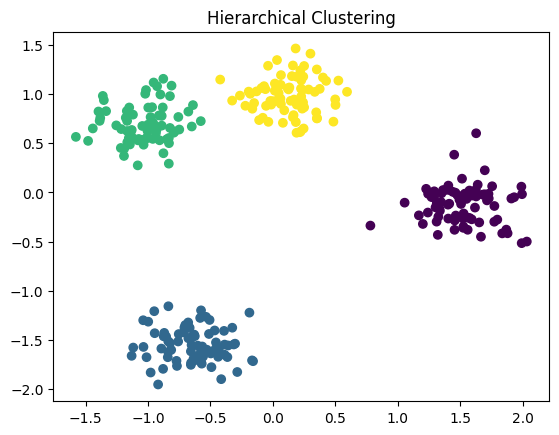

In [5]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=labels, cmap='viridis')

plt.title("Hierarchical Clustering")
plt.show()